In [3]:
# 🔧 KEEP — rebuild df: parse DDD dataset filenames into prefix/num/label/filepath
import os, re
import pandas as pd

DATA_ROOT = "/kaggle/input/datasets/ismailnasri20/driver-drowsiness-dataset-ddd/Driver Drowsiness Dataset (DDD)"

pattern = re.compile(r"^(?P<prefix>[A-Za-z]+)(?P<num>\d+)$")

records = []
for label_folder in ['Drowsy', 'Non Drowsy']:
    folder_path = os.path.join(DATA_ROOT, label_folder)
    for f in os.listdir(folder_path):
        if not f.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue
        name = os.path.splitext(f)[0]
        m = pattern.match(name)
        if m:
            records.append({
                'prefix': m.group('prefix').lower(),
                'num': int(m.group('num')),
                'label': label_folder,
                'filepath': os.path.join(folder_path, f)
            })
        else:
            records.append({'prefix': 'UNPARSED', 'num': None, 'label': label_folder,
                             'filepath': os.path.join(folder_path, f)})

df = pd.DataFrame(records)
print("Total files:", len(df))
print("Unparsed:", (df['prefix'] == 'UNPARSED').sum())

Total files: 41793
Unparsed: 0


In [4]:
# 🔧 KEEP — build manifest with subject (prefix), label, seq (num), and run detection
import pandas as pd
import numpy as np

df['subject'] = df['prefix']
df['seq'] = df['num']
df['label_clean'] = df['label'].map({'Drowsy': 'drowsy', 'Non Drowsy': 'notdrowsy'})

# Run/gap detection (same logic as before, now per subject+label since no "category" subfolders here)
GAP_THRESHOLD = 1
run_records = []
for (subj, label), group in df.groupby(['subject', 'label_clean']):
    group = group.sort_values('seq').reset_index(drop=True)
    run_id, prev_seq = 0, None
    for idx, row in group.iterrows():
        if prev_seq is not None and (row['seq'] - prev_seq) > GAP_THRESHOLD:
            run_id += 1
        run_records.append({'subject': subj, 'label': label, 'run_id': run_id,
                             'seq': row['seq'], 'filepath': row['filepath']})
        prev_seq = row['seq']

runs_df = pd.DataFrame(run_records)
runs_df['run_key'] = runs_df['subject'] + '_' + runs_df['label'] + '_' + runs_df['run_id'].astype(str)

check = runs_df.groupby('run_key')['label'].nunique()
print("Run_keys with mixed labels (should be 0):", (check > 1).sum())

run_lengths = runs_df.groupby('run_key').size()
print("\nTotal sub-runs:", run_lengths.shape[0])
print(run_lengths.describe())

print("\nUnique subjects:", runs_df['subject'].nunique())
print("Runs per subject (avg):", runs_df.groupby('subject')['run_key'].nunique().mean())

runs_df.to_csv('/kaggle/working/ddd2_runs_manifest.csv', index=False)
print("\nSaved.")

Run_keys with mixed labels (should be 0): 0

Total sub-runs: 1172
count    1172.000000
mean       35.659556
std        86.126261
min         1.000000
25%         3.000000
50%         9.000000
75%        28.000000
max      1228.000000
dtype: float64

Unique subjects: 28
Runs per subject (avg): 41.857142857142854

Saved.


In [6]:
# 🔧 KEEP — sliding windows (window=5, stride=2) + subject-level train/val/test split
import pandas as pd
import numpy as np

runs_df = pd.read_csv('/kaggle/working/ddd2_runs_manifest.csv')

WINDOW, STRIDE = 5, 2

window_records = []
for run_key, group in runs_df.groupby('run_key'):
    group = group.sort_values('seq').reset_index(drop=True)
    label = group['label'].iloc[0]
    subject = group['subject'].iloc[0]
    filepaths = group['filepath'].tolist()
    n = len(filepaths)
    for start in range(0, max(0, n - WINDOW + 1), STRIDE):
        window_records.append({
            'run_key': run_key, 'subject': subject, 'label': label,
            'start_idx': start, 'filepaths': filepaths[start:start + WINDOW]
        })

windows_df = pd.DataFrame(window_records)
print("Total sequences:", len(windows_df))
print(windows_df.groupby('label').size())

# Subject-level split: with 28 real subjects, do this properly this time
subjects = sorted(windows_df['subject'].unique())
np.random.seed(42)
np.random.shuffle(subjects)

n_train = int(len(subjects) * 0.70)
n_val = int(len(subjects) * 0.15)
train_subs = subjects[:n_train]
val_subs = subjects[n_train:n_train + n_val]
test_subs = subjects[n_train + n_val:]

print(f"\nTrain subjects ({len(train_subs)}): {train_subs}")
print(f"Val subjects ({len(val_subs)}): {val_subs}")
print(f"Test subjects ({len(test_subs)}): {test_subs}")

def assign_split(subj):
    if subj in train_subs: return 'train'
    if subj in val_subs: return 'val'
    return 'test'

windows_df['split'] = windows_df['subject'].apply(assign_split)
windows_df['y'] = (windows_df['label'] == 'drowsy').astype(int)

print("\nSequences per split+label:")
print(windows_df.groupby(['split', 'label']).size())

windows_df.to_pickle('/kaggle/working/ddd2_windows_index.pkl')
print("\nSaved ddd2_windows_index.pkl")

Total sequences: 19105
label
drowsy       10243
notdrowsy     8862
dtype: int64

Train subjects (19): ['j', 'za', 'i', 'v', 'a', 'm', 'r', 'w', 'l', 'n', 'p', 'b', 'e', 'f', 'c', 'q', 'x', 'd', 'zb']
Val subjects (4): ['y', 's', 'zc', 'u']
Test subjects (5): ['h', 'k', 'o', 't', 'g']

Sequences per split+label:
split  label    
test   drowsy       1630
       notdrowsy     861
train  drowsy       7102
       notdrowsy    6357
val    drowsy       1511
       notdrowsy    1644
dtype: int64

Saved ddd2_windows_index.pkl


In [7]:
# 🔧 KEEP — rebuild cache with CLAHE-based brightness/contrast normalization (removes the brightness shortcut)
import cv2
import numpy as np
import pandas as pd
import os
from tqdm import tqdm

runs_df = pd.read_csv('/kaggle/working/ddd2_runs_manifest.csv')
IMG_SIZE = 96
CACHE_DIR = '/kaggle/working/ddd2_cache_normalized'
os.makedirs(CACHE_DIR, exist_ok=True)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))

def process_and_cache(filepath):
    fname = filepath.replace('/', '_') + '.npy'
    out_path = os.path.join(CACHE_DIR, fname)
    if os.path.exists(out_path):
        return out_path
    img = cv2.imread(filepath)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    equalized = clahe.apply(gray)  # normalizes local contrast/brightness
    resized = cv2.resize(equalized, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
    np.save(out_path, resized.astype(np.uint8))
    return out_path

all_paths = runs_df['filepath'].unique().tolist()
cache_map = {}
for fp in tqdm(all_paths, desc="Re-caching with CLAHE"):
    result = process_and_cache(fp)
    if result:
        cache_map[fp] = result

runs_df['cache_path_norm'] = runs_df['filepath'].map(cache_map)
runs_df.to_csv('/kaggle/working/ddd2_runs_manifest.csv', index=False)
print(f"Done. Cached: {len(cache_map)}/{len(all_paths)}")

Re-caching with CLAHE: 100%|██████████| 41793/41793 [09:05<00:00, 76.61it/s]


Done. Cached: 41793/41793


In [8]:
# 🔧 KEEP — add explicit mean-brightness normalization on top of CLAHE
import cv2
import numpy as np
import pandas as pd
import os
from tqdm import tqdm

runs_df = pd.read_csv('/kaggle/working/ddd2_runs_manifest.csv')
IMG_SIZE = 96
CACHE_DIR = '/kaggle/working/ddd2_cache_normalized_v2'
os.makedirs(CACHE_DIR, exist_ok=True)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
TARGET_MEAN = 128.0

def process_and_cache(filepath):
    fname = filepath.replace('/', '_') + '.npy'
    out_path = os.path.join(CACHE_DIR, fname)
    if os.path.exists(out_path):
        return out_path
    img = cv2.imread(filepath)
    if img is None:
        return None
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    equalized = clahe.apply(gray)

    # Force mean brightness to a fixed target, clipping to valid range
    current_mean = equalized.mean()
    if current_mean > 0:
        shift = TARGET_MEAN - current_mean
        equalized = np.clip(equalized.astype(np.float32) + shift, 0, 255).astype(np.uint8)

    resized = cv2.resize(equalized, (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA)
    np.save(out_path, resized.astype(np.uint8))
    return out_path

all_paths = runs_df['filepath'].unique().tolist()
cache_map = {}
for fp in tqdm(all_paths, desc="Re-caching with CLAHE + mean normalization"):
    result = process_and_cache(fp)
    if result:
        cache_map[fp] = result

runs_df['cache_path_norm2'] = runs_df['filepath'].map(cache_map)
runs_df.to_csv('/kaggle/working/ddd2_runs_manifest.csv', index=False)
print(f"Done. Cached: {len(cache_map)}/{len(all_paths)}")

Re-caching with CLAHE + mean normalization: 100%|██████████| 41793/41793 [03:05<00:00, 225.70it/s]


Done. Cached: 41793/41793


In [10]:
# 🔧 KEEP — generator pointing at the fully normalized cache
import numpy as np
import pandas as pd
from tensorflow import keras

windows_df = pd.read_pickle('/kaggle/working/ddd2_windows_index.pkl')
runs_df = pd.read_csv('/kaggle/working/ddd2_runs_manifest.csv')
path_to_cache = dict(zip(runs_df['filepath'], runs_df['cache_path_norm2']))
windows_df['cache_paths'] = windows_df['filepaths'].apply(lambda fl: [path_to_cache[f] for f in fl])

IMG_SIZE, SEQ_LEN = 96, 5

class DrowsinessSequence(keras.utils.Sequence):
    def __init__(self, df, batch_size=16, shuffle=True, augment=False):
        super().__init__()
        self.df = df.reset_index(drop=True)
        self.batch_size = batch_size
        self.shuffle = shuffle
        self.augment = augment
        self.indices = np.arange(len(self.df))
        self.on_epoch_end()
    def __len__(self):
        return int(np.ceil(len(self.df) / self.batch_size))
    def on_epoch_end(self):
        if self.shuffle:
            np.random.shuffle(self.indices)
    def __getitem__(self, idx):
        batch_idx = self.indices[idx*self.batch_size:(idx+1)*self.batch_size]
        batch = self.df.iloc[batch_idx]
        X = np.zeros((len(batch), SEQ_LEN, IMG_SIZE, IMG_SIZE, 1), dtype=np.float32)
        y = np.zeros((len(batch),), dtype=np.float32)
        for i, (_, row) in enumerate(batch.iterrows()):
            do_flip = self.augment and np.random.rand() < 0.5
            frames = []
            for cp in row['cache_paths']:
                f = np.load(cp).astype(np.float32) / 255.0
                if self.augment:
                    if do_flip:
                        f = np.fliplr(f)
                    alpha = np.random.uniform(0.9, 1.1)  # mild jitter only — brightness is now controlled, don't reintroduce a big swing
                    f = np.clip(f * alpha, 0.0, 1.0)
                frames.append(f)
            X[i] = np.stack(frames, axis=0)[..., np.newaxis]
            y[i] = row['y']
        return X, y

train_gen = DrowsinessSequence(windows_df[windows_df['split']=='train'], batch_size=16, shuffle=True, augment=True)
val_gen   = DrowsinessSequence(windows_df[windows_df['split']=='val'], batch_size=16, shuffle=False, augment=False)
test_gen  = DrowsinessSequence(windows_df[windows_df['split']=='test'], batch_size=16, shuffle=False, augment=False)

print("Batches — train:", len(train_gen), "val:", len(val_gen), "test:", len(test_gen))

Batches — train: 842 val: 198 test: 156


In [16]:
# 🔧 KEEP — Cell A: reproducibility seeds (run FIRST, before building/training anything)
import os
import random
import numpy as np
import tensorflow as tf

SEED = 42
os.environ['PYTHONHASHSEED'] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"Seeds set to {SEED}")
# 🔧 KEEP — model architecture: CNN (pretrained MobileNetV2 backbone) + LSTM + Attention

Seeds set to 42


In [17]:
# 🔧 KEEP — Cell B: model architecture (same as before, unchanged)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.applications import MobileNetV2

IMG_SIZE = 96
SEQ_LEN = 5

class AttentionLayer(layers.Layer):
    def __init__(self, units=64, **kwargs):
        super().__init__(**kwargs)
        self.units = units
    def build(self, input_shape):
        self.W = self.add_weight(name="att_W", shape=(input_shape[-1], self.units), initializer="glorot_uniform", trainable=True)
        self.b = self.add_weight(name="att_b", shape=(self.units,), initializer="zeros", trainable=True)
        self.u = self.add_weight(name="att_u", shape=(self.units, 1), initializer="glorot_uniform", trainable=True)
        super().build(input_shape)
    def call(self, inputs):
        score = tf.nn.tanh(tf.tensordot(inputs, self.W, axes=1) + self.b)
        score = tf.tensordot(score, self.u, axes=1)
        weights = tf.nn.softmax(score, axis=1)
        context = tf.reduce_sum(inputs * weights, axis=1)
        return context, weights

def build_model_transfer():
    inputs = layers.Input(shape=(SEQ_LEN, IMG_SIZE, IMG_SIZE, 1))
    rgb = layers.TimeDistributed(layers.Lambda(lambda t: tf.repeat(t, 3, axis=-1)))(inputs)
    base = MobileNetV2(input_shape=(IMG_SIZE, IMG_SIZE, 3), include_top=False, weights='imagenet', pooling='avg')
    base.trainable = False
    x = layers.TimeDistributed(base)(rgb)
    x = layers.TimeDistributed(layers.Dense(128, activation='relu'))(x)
    x = layers.LSTM(128, return_sequences=True, dropout=0.2, recurrent_dropout=0.2)(x)
    x = layers.Dropout(0.4)(x)
    context, attn_weights = AttentionLayer(units=64)(x)
    x = layers.Dense(64, activation='relu', kernel_regularizer=regularizers.l2(1e-4))(context)
    x = layers.Dropout(0.4)(x)
    outputs = layers.Dense(1, activation='sigmoid')(x)
    return keras.Model(inputs=inputs, outputs=outputs)

print("Model function defined.")

Model function defined.


In [18]:
# 🔧 KEEP — Cell C: verify data pipeline survived (run this, confirm no errors, before training)
print("windows_df:", len(windows_df))
print("train_gen batches:", len(train_gen), "val_gen:", len(val_gen), "test_gen:", len(test_gen))

windows_df: 19105
train_gen batches: 842 val_gen: 198 test_gen: 156


Epoch 1/30
842/842 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.8192 - loss: 0.3871 - precision: 0.8230 - recall: 0.8369
Epoch 1: val_accuracy improved from None to 0.74580, saving model to /kaggle/working/final_model.keras

Epoch 1: finished saving model to /kaggle/working/final_model.keras
842/842 ━━━━━━━━━━━━━━━━━━━━ 83s 72ms/step - accuracy: 0.9239 - loss: 0.1937 - precision: 0.9246 - recall: 0.9319 - val_accuracy: 0.7458 - val_loss: 0.9861 - val_precision: 0.7908 - val_recall: 0.6380 - learning_rate: 1.0000e-04
Epoch 2/30
841/842 ━━━━━━━━━━━━━━━━━━━━ 0s 53ms/step - accuracy: 0.9966 - loss: 0.0207 - precision: 0.9978 - recall: 0.9959
Epoch 2: val_accuracy improved from 0.74580 to 0.81490, saving model to /kaggle/working/final_model.keras

Epoch 2: finished saving model to /kaggle/working/final_model.keras
842/842 ━━━━━━━━━━━━━━━━━━━━ 53s 63ms/step - accuracy: 0.9970 - loss: 0.0185 - precision: 0.9973 - recall: 0.9970 - val_accuracy: 0.8149 - val_loss: 0.8880 - val_precision: 0.8

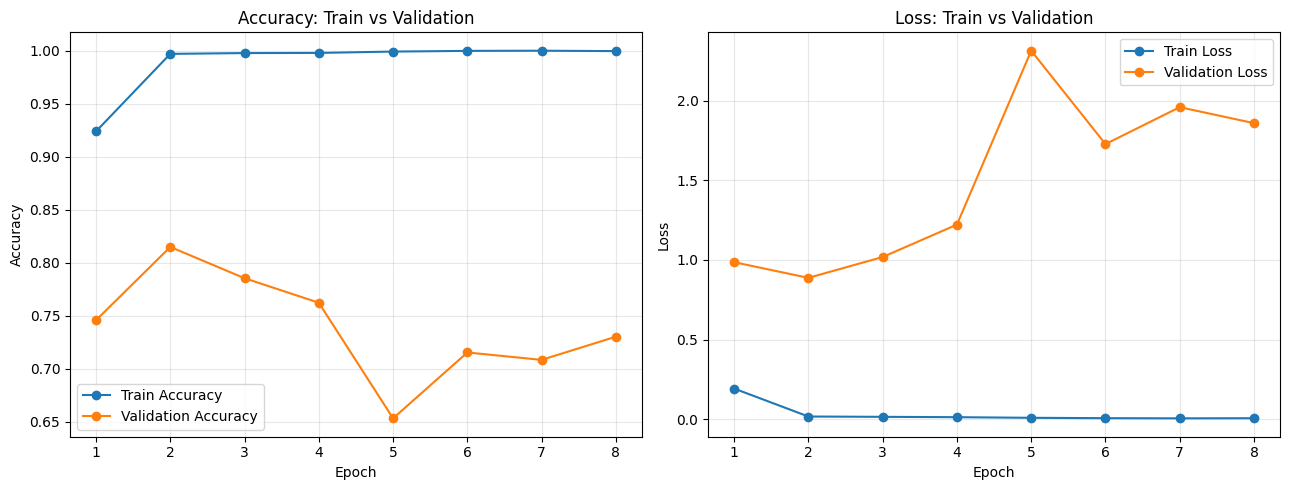

Classification Report:
               precision    recall  f1-score   support

   notdrowsy       0.55      0.98      0.70       861
      drowsy       0.98      0.57      0.72      1630

    accuracy                           0.71      2491
   macro avg       0.76      0.77      0.71      2491
weighted avg       0.83      0.71      0.71      2491

Confusion Matrix:
 [[842  19]
 [700 930]]

=== ALL ARTIFACTS SAVED: final_model.keras, final_model.weights.h5, training_curves.png, classification_report.txt ===


In [33]:
# 🔧 KEEP — Cell D: train, then IMMEDIATELY plot + evaluate + save, all in one cell run
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

model_final = build_model_transfer()
model_final.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=['accuracy', keras.metrics.Precision(name='precision'), keras.metrics.Recall(name='recall')]
)

train_labels = windows_df[windows_df['split'] == 'train']['y'].values
cw_arr = compute_class_weight('balanced', classes=np.unique(train_labels), y=train_labels)
class_weights = {i: w for i, w in enumerate(cw_arr)}

callbacks_final = [
    keras.callbacks.ModelCheckpoint('/kaggle/working/final_model.keras', monitor='val_accuracy', mode='max', save_best_only=True, verbose=1),
    keras.callbacks.EarlyStopping(monitor='val_accuracy', mode='max', patience=6, restore_best_weights=True, verbose=1),
    keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
]

history_final = model_final.fit(
    train_gen, validation_data=val_gen, epochs=30,
    class_weight=class_weights, callbacks=callbacks_final, verbose=1
)

print("\n=== TRAINING DONE — saving everything now, in this same cell run ===\n")

# Save weights immediately
model_final.save_weights('/kaggle/working/final_model.weights.h5')

# Plot immediately from the LIVE history object (guaranteed to match this exact run)
h = history_final.history
epochs_range = range(1, len(h['accuracy']) + 1)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(epochs_range, h['accuracy'], label='Train Accuracy', marker='o')
axes[0].plot(epochs_range, h['val_accuracy'], label='Validation Accuracy', marker='o')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Accuracy'); axes[0].set_title('Accuracy: Train vs Validation')
axes[0].legend(); axes[0].grid(alpha=0.3)
axes[1].plot(epochs_range, h['loss'], label='Train Loss', marker='o')
axes[1].plot(epochs_range, h['val_loss'], label='Validation Loss', marker='o')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Loss'); axes[1].set_title('Loss: Train vs Validation')
axes[1].legend(); axes[1].grid(alpha=0.3)
plt.tight_layout()
plt.savefig('/kaggle/working/training_curves.png', dpi=150)
plt.show()

# Evaluate on test set immediately, from THIS model, right now
test_windows = windows_df[windows_df['split'] == 'test'].reset_index(drop=True)
y_true, y_pred_prob, subjects = [], [], []
for i in range(len(test_gen)):
    Xb, yb = test_gen[i]
    preds = model_final.predict(Xb, verbose=0)
    start = i * test_gen.batch_size
    end = start + len(yb)
    batch_subjects = test_windows.iloc[test_gen.indices[start:end]]['subject'].tolist()
    y_true.extend(yb.tolist())
    y_pred_prob.extend(preds.flatten().tolist())
    subjects.extend(batch_subjects)

y_true = np.array(y_true)
y_pred = (np.array(y_pred_prob) >= 0.5).astype(int)

report = classification_report(y_true, y_pred, target_names=['notdrowsy', 'drowsy'])
cm = confusion_matrix(y_true, y_pred)
print("Classification Report:\n", report)
print("Confusion Matrix:\n", cm)

with open('/kaggle/working/classification_report.txt', 'w') as f:
    f.write(report)
    f.write("\n\nConfusion Matrix:\n")
    f.write(str(cm))

print("\n=== ALL ARTIFACTS SAVED: final_model.keras, final_model.weights.h5, training_curves.png, classification_report.txt ===")

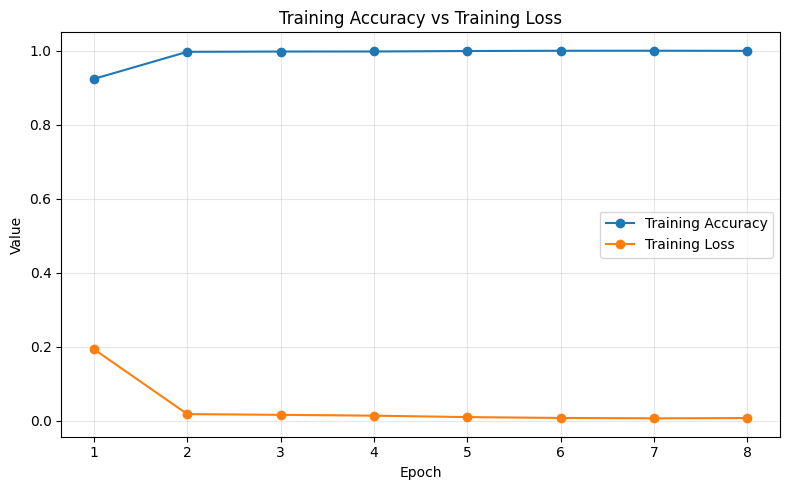

In [34]:
h = history_final.history
epochs_range = range(1, len(h['accuracy']) + 1)

plt.figure(figsize=(8, 5))

plt.plot(epochs_range, h['accuracy'],
         label='Training Accuracy', marker='o')

plt.plot(epochs_range, h['loss'],
         label='Training Loss', marker='o')

plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Training Accuracy vs Training Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/training_accuracy_vs_loss.png', dpi=150)
plt.show()

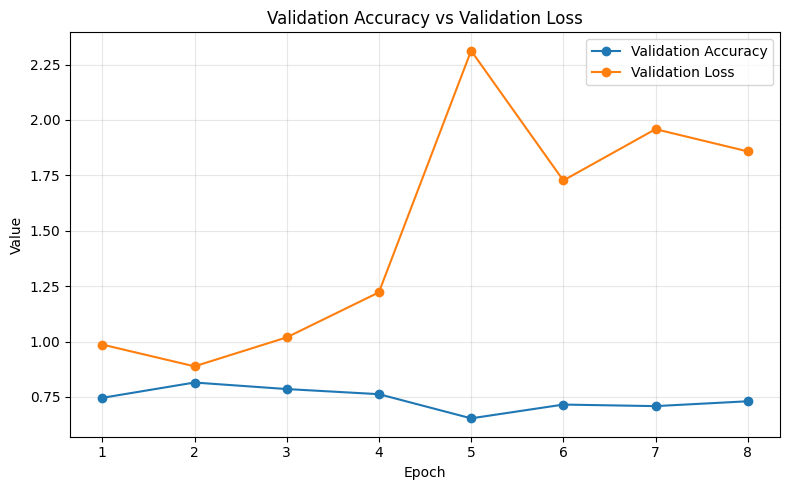

In [35]:
plt.figure(figsize=(8, 5))

plt.plot(epochs_range, h['val_accuracy'],
         label='Validation Accuracy', marker='o')

plt.plot(epochs_range, h['val_loss'],
         label='Validation Loss', marker='o')

plt.xlabel('Epoch')
plt.ylabel('Value')
plt.title('Validation Accuracy vs Validation Loss')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/validation_accuracy_vs_loss.png', dpi=150)
plt.show()